# Transaction Fraud Detection

This notebook detects fraud at the **transaction level** - meaning we predict if each individual transaction is fraudulent.

In [0]:
# Install packages we need
%pip install scikit-learn matplotlib seaborn --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("Libraries loaded!")
print(f"Ready to detect fraud!")

Libraries loaded!
Ready to detect fraud!


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Load transactions from database
df = spark.table("ddca_catalog.silver.transactions_silver")

df_pandas = df.toPandas()

print(f"Loaded {len(df_pandas):,} transactions")
print(f"Number of columns: {len(df_pandas.columns)}")
print("\nColumn names:")
for col in df_pandas.columns:
    print(f"  - {col}")

print("\nFirst few transactions:")
display(df_pandas.head())

Loaded 497,691 transactions
Number of columns: 12

Column names:
  - id
  - customer_id
  - distance_from_home
  - distance_from_last_transaction
  - ratio_to_median_purchase_price
  - is_repeat_retailer
  - used_chip
  - used_pin
  - is_online_order
  - is_fraud
  - timestamp
  - ingestion_time

First few transactions:


id,customer_id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,is_repeat_retailer,used_chip,used_pin,is_online_order,is_fraud,timestamp,ingestion_time
c1d78d81-0c16-4b26-ac10-c21c44e595a6,2826,57.877857,0.31114,1.94594,true,true,false,false,false,null,2026-04-19T18:24:30.234Z
4b099b48-762e-48d5-914e-d57532bab5f0,291,10.829943,0.1755915,1.2942188,true,false,false,false,false,null,2026-04-19T18:24:30.234Z
6db91f9b-a950-4ea6-afdc-104d3bf3551b,1919,44.190937,0.56648624,2.2227674,true,true,false,true,false,null,2026-04-19T18:24:30.234Z
baaf1bfc-db33-4f2d-b5a7-2f124f588c60,397,5.5864077,13.261073,0.06476846,true,false,false,false,false,null,2026-04-19T18:24:30.234Z
8dadddbe-d893-4e22-ac5d-4faeeeb1b069,735,3.724019,0.95683795,0.27846494,true,false,false,true,false,null,2026-04-19T18:24:30.234Z


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

Fraud Distribution:
False    459815
True      37876
Name: is_fraud, dtype: int64

Fraud rate: 7.61%


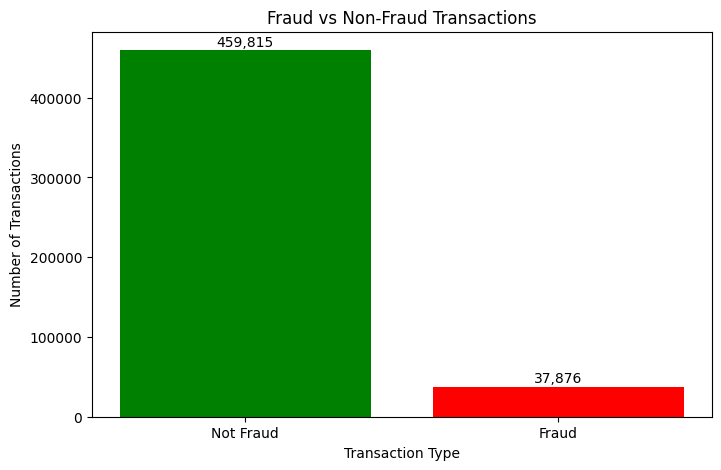

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Fraud vs non-fraud transactions graph
print("Fraud Distribution:")
fraud_counts = df_pandas['is_fraud'].value_counts()
print(fraud_counts)
print(f"\nFraud rate: {fraud_counts[True] / len(df_pandas) * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(['Not Fraud', 'Fraud'], [fraud_counts[False], fraud_counts[True]], color=['green', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.ylabel('Number of Transactions')
plt.xlabel('Transaction Type')
for i, v in enumerate([fraud_counts[False], fraud_counts[True]]):
    plt.text(i, v + 5000, f'{v:,}', ha='center')
plt.show()

In [0]:
# Basic statistics
print("Basic statistics for numerical features:")
display(df_pandas.describe())

print("\nData types:")
print(df_pandas.dtypes)

Basic statistics for numerical features:


customer_id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
497691.0,497691.0,497691.0,497691.0
1871.0526792728822,26.00823402404785,4.925481796264648,1.778139591217041
946.7434105078211,60.71714401245117,27.208232879638672,2.730908155441284
1.0,0.0048743849620223045,3.378936380613595E-4,0.005741060711443424
1024.0,3.869803547859192,0.29671433568000793,0.4720440059900284
2156.0,9.93109130859375,0.9974233508110046,0.9852433204650879
2770.0,25.47177505493164,3.3455724716186523,2.0562145709991455
2999.0,4601.01123046875,11851.1044921875,266.689697265625



Data types:
id                                        object
customer_id                                int32
distance_from_home                       float32
distance_from_last_transaction           float32
ratio_to_median_purchase_price           float32
is_repeat_retailer                          bool
used_chip                                   bool
used_pin                                    bool
is_online_order                             bool
is_fraud                                    bool
timestamp                         datetime64[ns]
ingestion_time                    datetime64[ns]
dtype: object


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

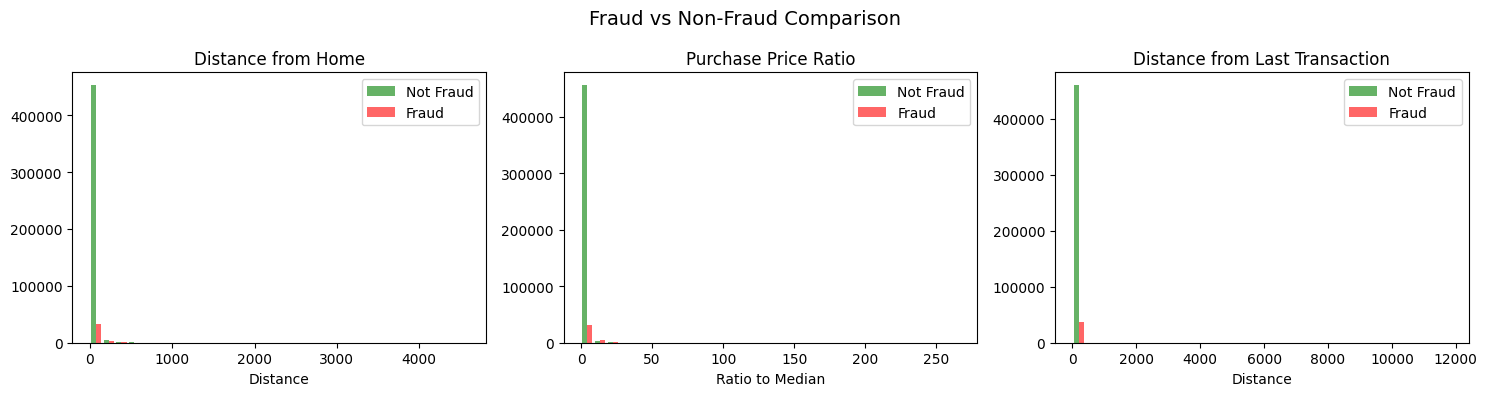

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Fraud vs non-fraud on key features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fraud vs Non-Fraud Comparison', fontsize=14)

# Distance from home
fraud_data = df_pandas[df_pandas['is_fraud'] == True]['distance_from_home']
no_fraud_data = df_pandas[df_pandas['is_fraud'] == False]['distance_from_home']
axes[0].hist([no_fraud_data, fraud_data], label=['Not Fraud', 'Fraud'], bins=30, color=['green', 'red'], alpha=0.6)
axes[0].set_title('Distance from Home')
axes[0].set_xlabel('Distance')
axes[0].legend()

# Purchase price ratio
fraud_data = df_pandas[df_pandas['is_fraud'] == True]['ratio_to_median_purchase_price']
no_fraud_data = df_pandas[df_pandas['is_fraud'] == False]['ratio_to_median_purchase_price']
axes[1].hist([no_fraud_data, fraud_data], label=['Not Fraud', 'Fraud'], bins=30, color=['green', 'red'], alpha=0.6)
axes[1].set_title('Purchase Price Ratio')
axes[1].set_xlabel('Ratio to Median')
axes[1].legend()

# Distance from last transaction
fraud_data = df_pandas[df_pandas['is_fraud'] == True]['distance_from_last_transaction']
no_fraud_data = df_pandas[df_pandas['is_fraud'] == False]['distance_from_last_transaction']
axes[2].hist([no_fraud_data, fraud_data], label=['Not Fraud', 'Fraud'], bins=30, color=['green', 'red'], alpha=0.6)
axes[2].set_title('Distance from Last Transaction')
axes[2].set_xlabel('Distance')
axes[2].legend()

plt.tight_layout()
plt.show()

In [0]:
df_ml = df_pandas.copy()

# Unecessary columns
df_ml = df_ml.drop(columns=['id', 'ingestion_time'])

# Convert boolean columns to numbers
boolean_cols = ['is_repeat_retailer', 'used_chip', 'used_pin', 'is_online_order', 'is_fraud']
for col in boolean_cols:
    df_ml[col] = df_ml[col].astype(int)

df_ml = df_ml.fillna(0)

print(f"Data prepared!")
print(f"Shape: {df_ml.shape}")
print(f"Columns: {list(df_ml.columns)}")

Data prepared!
Shape: (497691, 10)
Columns: ['customer_id', 'distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'is_repeat_retailer', 'used_chip', 'used_pin', 'is_online_order', 'is_fraud', 'timestamp']


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Separate features from target
y = df_ml['is_fraud']  # prediction target
X = df_ml.drop('is_fraud', axis=1)

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

# split into training and testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {len(X_train):,} transactions")
print(f"Test set: {len(X_test):,} transactions")

Features (X): (497691, 9)
Target (y): (497691,)

Feature names: ['customer_id', 'distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'is_repeat_retailer', 'used_chip', 'used_pin', 'is_online_order', 'timestamp']

Training set: 398,152 transactions
Test set: 99,539 transactions


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Train a Random Forest model
print("Training model...")

model = RandomForestClassifier(
    n_estimators=100,  
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained!")
print(f"Used {len(X_train):,} transactions to train")

Training model...
Model trained!
Used 398,152 transactions to train


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance:\n")
print(f"Accuracy:  {accuracy:.2%} (how often it's correct overall)")
print(f"Precision: {precision:.2%} (when it says fraud, how often is it right)")
print(f"Recall:    {recall:.2%} (how many actual frauds did it catch)")
print(f"F1 Score:  {f1:.2%} (balance between precision and recall)")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

Model Performance:

Accuracy:  100.00% (how often it's correct overall)
Precision: 100.00% (when it says fraud, how often is it right)
Recall:    99.97% (how many actual frauds did it catch)
F1 Score:  99.99% (balance between precision and recall)

Detailed Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     91769
       Fraud       1.00      1.00      1.00      7770

    accuracy                           1.00     99539
   macro avg       1.00      1.00      1.00     99539
weighted avg       1.00      1.00      1.00     99539



com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

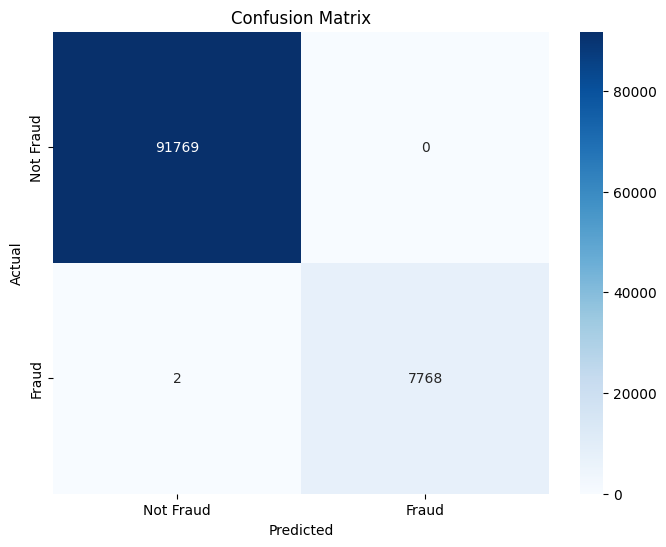


What this means:
Correctly identified legitimate transactions: 91,769
False alarms (flagged as fraud but wasn't): 0
Missed frauds (didn't catch): 2
Correctly caught frauds: 7,768


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nWhat this means:")
print(f"Correctly identified legitimate transactions: {cm[0, 0]:,}")
print(f"False alarms (flagged as fraud but wasn't): {cm[0, 1]:,}")
print(f"Missed frauds (didn't catch): {cm[1, 0]:,}")
print(f"Correctly caught frauds: {cm[1, 1]:,}")

Feature Importance Rankings:
                          feature  importance
3  ratio_to_median_purchase_price    0.495487
7                 is_online_order    0.174911
1              distance_from_home    0.115594
6                        used_pin    0.075429
5                       used_chip    0.060162
2  distance_from_last_transaction    0.038884
0                     customer_id    0.030305
4              is_repeat_retailer    0.009227
8                       timestamp    0.000000


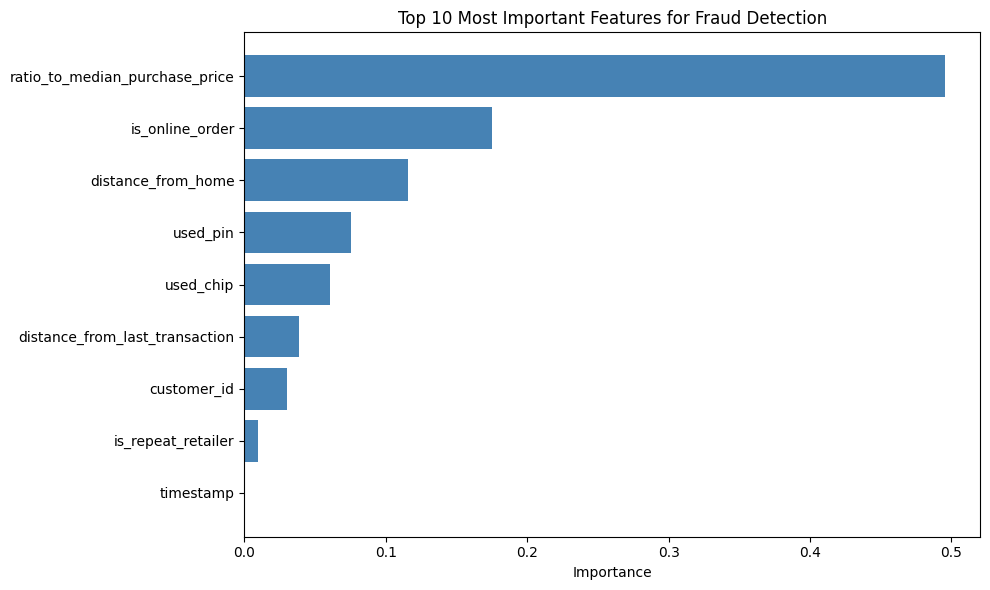

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importance Rankings:")
print(feature_importance_df)

# Plot the top 10
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(range(len(top_10)), top_10['importance'], color='steelblue')
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [0]:
print("Making predictions for all transactions...\n")

all_predictions = model.predict(X)
all_probabilities = model.predict_proba(X)[:, 1]  # Probability of being fraud

results = pd.DataFrame({
    'transaction_id': df_pandas['id'],
    'customer_id': df_pandas['customer_id'],
    'actual_fraud': df_pandas['is_fraud'],
    'predicted_fraud': all_predictions.astype(bool),
    'fraud_probability': all_probabilities,
    'timestamp': df_pandas['timestamp']
})

results['risk_level'] = 'Low'
results.loc[results['fraud_probability'] > 0.3, 'risk_level'] = 'Medium'
results.loc[results['fraud_probability'] > 0.7, 'risk_level'] = 'High'

print(f"Predictions made for {len(results):,} transactions")
print(f"\nRisk Level Distribution:")
print(results['risk_level'].value_counts())

print("\nSample predictions:")
display(results.head(10))

Making predictions for all transactions...

Predictions made for 497,691 transactions

Risk Level Distribution:
Low       459814
High       37865
Medium        12
Name: risk_level, dtype: int64

Sample predictions:


transaction_id,customer_id,actual_fraud,predicted_fraud,fraud_probability,timestamp,risk_level
c1d78d81-0c16-4b26-ac10-c21c44e595a6,2826,false,false,0.0,null,Low
4b099b48-762e-48d5-914e-d57532bab5f0,291,false,false,3.898572555770748E-4,null,Low
6db91f9b-a950-4ea6-afdc-104d3bf3551b,1919,false,false,6.780956334340137E-7,null,Low
baaf1bfc-db33-4f2d-b5a7-2f124f588c60,397,false,false,2.398081534772182E-5,null,Low
8dadddbe-d893-4e22-ac5d-4faeeeb1b069,735,false,false,0.0031023671211005545,null,Low
299c0250-2121-4942-82b5-4a706bb33db6,518,false,false,0.0016916836854051936,null,Low
aacbb504-d9fb-4dbb-a78b-b19b84f91828,1896,false,false,0.0032913544765988683,null,Low
ab651ed6-76e7-4bb9-b84f-75d280fa08ea,101,false,false,6.780956334340137E-7,null,Low
eb9961dd-6960-4e1a-9f55-22aece1dcf49,1896,false,false,0.003680926216603408,null,Low
d0f41006-5a8a-4ff5-9a0c-b4e45230f459,2770,false,false,3.9571310799670236E-4,null,Low


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:434)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:510)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:616)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$4(UsageLogging.scala:643)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:49)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:293)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:62)
	at com.databricks.logging.AttributionContext$.withValue(Attr

In [0]:
print("Saving predictions...\n")

results_spark = spark.createDataFrame(results)

table_name = "ddca_catalog.gold.transaction_fraud_predictions"
results_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(table_name)

print(f"Saved to {table_name}")
print(f"Total predictions: {len(results):,}")

print("\nVerifying saved data:")
saved_data = spark.table(table_name)
print(f"Rows in table: {saved_data.count():,}")
display(saved_data.limit(5))

Saving predictions...

Saved to ddca_catalog.gold.transaction_fraud_predictions
Total predictions: 497,691

Verifying saved data:
Rows in table: 497,691


transaction_id,customer_id,actual_fraud,predicted_fraud,fraud_probability,timestamp,risk_level
c1d78d81-0c16-4b26-ac10-c21c44e595a6,2826,false,false,0.0,null,Low
4b099b48-762e-48d5-914e-d57532bab5f0,291,false,false,3.898572555770748E-4,null,Low
6db91f9b-a950-4ea6-afdc-104d3bf3551b,1919,false,false,6.780956334340137E-7,null,Low
baaf1bfc-db33-4f2d-b5a7-2f124f588c60,397,false,false,2.398081534772182E-5,null,Low
8dadddbe-d893-4e22-ac5d-4faeeeb1b069,735,false,false,0.0031023671211005545,null,Low


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4765694509875765>, line 9
      7 # Save to gold layer
      8 table_name = "ddca_catalog.gold.transaction_fraud_predictions"
----> 9 results_spark.write.mode("overwrite").saveAsTable(table_name)
     11 print(f"Saved to {table_name}")
     12 print(f"Total predictions: {len(results):,}")

File /databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/readwriter.py:713, in DataFrameWriter.saveAsTable(self, name, format, mode, partitionBy, **options)
    711 self._write.table_name = name
    712 self._write.table_save_method = "save_as_table"
--> 713 _, _, ei = self._spark.client.execute_command(
    714     self._write.command(self._spark.client), self._write.observations
    715 )
    716 self._callback(ei)

File /databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/client/core.py:1306, in SparkCon